# Bank Transaction Fraud Data Analysis Using Python And Data Science

### Import libraries

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime

# Data load

In [2]:
df = pd.read_csv("Bank_Transaction_Fraud_Detection.csv")
df

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,b8bdae19-296f-48b7-9104-e055d33a09ac,Vedhika Magar,Female,55,Dadra and Nagar Haveli and Daman and Diu,Diu,Diu Branch,Business,8d856bc7-4666-4509-a067-48d67500694a,08-01-2025,...,Restaurant,37475.11,Desktop/Laptop,"Diu, Dadra and Nagar Haveli and Daman and Diu",ATM,0,INR,+9192629XXXXXX,ATM withdrawal,vedhikaXXXXX@XXXXXXX.com
199996,635bc099-8a93-48ee-829a-bf2283fe8fda,Aashi Pai,Male,51,Manipur,Kangpokpi,Kangpokpi Branch,Business,f2890dbd-4e01-445d-97f5-ac56886e9037,01-01-2025,...,Groceries,53037.20,ATM,"Kangpokpi, Manipur",ATM,0,INR,+9198116XXXXXX,Subscription box,aashiXXX@XXXXXX.com
199997,c1b31cc2-0905-47e8-8cc5-6461d1f3ba33,Dayita Shan,Female,41,Chandigarh,Chandigarh,Chandigarh Branch,Savings,f714b758-7539-474d-b676-5fa7e2480141,28-01-2025,...,Health,96225.36,ATM,"Chandigarh, Chandigarh",Desktop,0,INR,+9192601XXXXXX,Charity donation,dayitaXXXX@XXXXXXX.com
199998,32bb8e66-f3fa-43bf-8242-dab9a6116310,Unnati Vyas,Female,28,Telangana,Nizamabad,Nizamabad Branch,Checking,f6903b6a-b582-47ea-95d5-aff16bdec950,08-01-2025,...,Electronics,89599.90,Voice Assistant,"Nizamabad, Telangana",Desktop,0,INR,+9197537XXXXXX,Tourist attraction payment,unnatiXXX@XXXXX.com


# Data Exploration

In [3]:
# Data exploration :- 
# It helps us understand the data clearly.
# We check the number of rows and columns.
# We check if there are any missing or duplicate values.

#### View the first 5 rows

In [4]:
df.head()

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


#### View the last 5 rows

In [5]:
df.tail()

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
199995,b8bdae19-296f-48b7-9104-e055d33a09ac,Vedhika Magar,Female,55,Dadra and Nagar Haveli and Daman and Diu,Diu,Diu Branch,Business,8d856bc7-4666-4509-a067-48d67500694a,08-01-2025,...,Restaurant,37475.11,Desktop/Laptop,"Diu, Dadra and Nagar Haveli and Daman and Diu",ATM,0,INR,+9192629XXXXXX,ATM withdrawal,vedhikaXXXXX@XXXXXXX.com
199996,635bc099-8a93-48ee-829a-bf2283fe8fda,Aashi Pai,Male,51,Manipur,Kangpokpi,Kangpokpi Branch,Business,f2890dbd-4e01-445d-97f5-ac56886e9037,01-01-2025,...,Groceries,53037.20,ATM,"Kangpokpi, Manipur",ATM,0,INR,+9198116XXXXXX,Subscription box,aashiXXX@XXXXXX.com
199997,c1b31cc2-0905-47e8-8cc5-6461d1f3ba33,Dayita Shan,Female,41,Chandigarh,Chandigarh,Chandigarh Branch,Savings,f714b758-7539-474d-b676-5fa7e2480141,28-01-2025,...,Health,96225.36,ATM,"Chandigarh, Chandigarh",Desktop,0,INR,+9192601XXXXXX,Charity donation,dayitaXXXX@XXXXXXX.com
199998,32bb8e66-f3fa-43bf-8242-dab9a6116310,Unnati Vyas,Female,28,Telangana,Nizamabad,Nizamabad Branch,Checking,f6903b6a-b582-47ea-95d5-aff16bdec950,08-01-2025,...,Electronics,89599.90,Voice Assistant,"Nizamabad, Telangana",Desktop,0,INR,+9197537XXXXXX,Tourist attraction payment,unnatiXXX@XXXXX.com
199999,f3dd92ef-b17a-45d2-b6cb-fdbee20843fe,Gopal Rout,Male,34,Nagaland,Kohima,Kohima Branch,Business,b44b6e8a-1036-4ec1-b492-5e7ffc7baf6d,08-01-2025,...,Electronics,15066.24,Virtual Card,"Kohima, Nagaland",Mobile,0,INR,+9193961XXXXXX,Installment payment,gopalXXXXX@XXXXXXX.com


#### Dataset information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              200000 non-null  str    
 1   Customer_Name            200000 non-null  str    
 2   Gender                   200000 non-null  str    
 3   Age                      200000 non-null  int64  
 4   State                    200000 non-null  str    
 5   City                     200000 non-null  str    
 6   Bank_Branch              200000 non-null  str    
 7   Account_Type             200000 non-null  str    
 8   Transaction_ID           200000 non-null  str    
 9   Transaction_Date         200000 non-null  str    
 10  Transaction_Time         200000 non-null  str    
 11  Transaction_Amount       200000 non-null  float64
 12  Merchant_ID              200000 non-null  str    
 13  Transaction_Type         200000 non-null  str    
 14  Merchant_Catego

In [7]:
df.dtypes

Customer_ID                    str
Customer_Name                  str
Gender                         str
Age                          int64
State                          str
City                           str
Bank_Branch                    str
Account_Type                   str
Transaction_ID                 str
Transaction_Date               str
Transaction_Time               str
Transaction_Amount         float64
Merchant_ID                    str
Transaction_Type               str
Merchant_Category              str
Account_Balance            float64
Transaction_Device             str
Transaction_Location           str
Device_Type                    str
Is_Fraud                     int64
Transaction_Currency           str
Customer_Contact               str
Transaction_Description        str
Customer_Email                 str
dtype: object

In [8]:
df.shape

(200000, 24)

In [9]:
df.columns

Index(['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'State', 'City',
       'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date',
       'Transaction_Time', 'Transaction_Amount', 'Merchant_ID',
       'Transaction_Type', 'Merchant_Category', 'Account_Balance',
       'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud',
       'Transaction_Currency', 'Customer_Contact', 'Transaction_Description',
       'Customer_Email'],
      dtype='str')

In [10]:
df.columns.tolist()

['Customer_ID',
 'Customer_Name',
 'Gender',
 'Age',
 'State',
 'City',
 'Bank_Branch',
 'Account_Type',
 'Transaction_ID',
 'Transaction_Date',
 'Transaction_Time',
 'Transaction_Amount',
 'Merchant_ID',
 'Transaction_Type',
 'Merchant_Category',
 'Account_Balance',
 'Transaction_Device',
 'Transaction_Location',
 'Device_Type',
 'Is_Fraud',
 'Transaction_Currency',
 'Customer_Contact',
 'Transaction_Description',
 'Customer_Email']

In [11]:
df["Customer_Name"].unique()

<ArrowStringArray>
[         'Osha Tella',     'Hredhaan Khosla',      'Ekani Nazareth',
 'Yamini Ramachandran',        'Kritika Rege',         'Ishanvi Dar',
         'Arya Shroff',       'Jackson Shere',     'Bhanumati Ravel',
        'Meera Ganesh',
 ...
     'Yashawini Dalal',   'Harini Ramanathan',        'Zayyan Parsa',
       'Charles Balay',    'Indali Chaudhari',           'Kai Anand',
         'Vivaan Keer',        'Aahana Mohan',         'Dayita Shan',
          'Gopal Rout']
Length: 142699, dtype: str

# Memory Usage

In [12]:
df.memory_usage()

Index                          132
Customer_ID                8800000
Customer_Name              4107362
Gender                     2599096
Age                        1600000
State                      3698313
City                       3117435
Bank_Branch                4517435
Account_Type               3133407
Transaction_ID             8800000
Transaction_Date           3600000
Transaction_Time           3200000
Transaction_Amount         1600000
Merchant_ID                8800000
Transaction_Type           3239204
Merchant_Category          3501333
Account_Balance            1600000
Transaction_Device         4475427
Transaction_Location       5615748
Device_Type                2549374
Is_Fraud                   1600000
Transaction_Currency       2200000
Customer_Contact           4400000
Transaction_Description    5036939
Customer_Email             5784743
dtype: int64

In [13]:
df.index

RangeIndex(start=0, stop=200000, step=1)

In [14]:
df.size

4800000

In [15]:
df.ndim

2

# Statistical Analysis

In [16]:
# describe only integer values

df.describe()

,Age,Transaction_Amount,Account_Balance,Is_Fraud
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,44.015110,49538.015554,52437.988784,0.050440
std,15.288774,28551.874004,27399.507128,0.218852
min,18.000000,10.290000,5000.820000,0.000000
25%,31.000000,24851.345000,28742.395000,0.000000
50%,44.000000,49502.440000,52372.555000,0.000000
75%,57.000000,74314.625000,76147.670000,0.000000
max,70.000000,98999.980000,99999.950000,1.000000


In [17]:
# describe all the integer and string values

df.describe(include="all")

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
count,200000,200000,200000,200000.000000,200000,200000,200000,200000,200000,200000,...,200000,200000.000000,200000,200000,200000,200000.000000,200000,200000,200000,200000
unique,200000,142699,2,NaN,34,145,145,3,200000,31,...,6,NaN,20,148,4,NaN,1,9000,172,4779
top,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Aahana Kala,Male,NaN,Nagaland,Chandigarh,Chandigarh Branch,Checking,4fa3208f-9e23-42dc-b330-844829d0c12c,29-01-2025,...,Restaurant,NaN,Self-service Banking Machine,"Kavaratti, Lakshadweep",POS,NaN,INR,+9191471XXXXXX,Sports ticket,krishnaXXX@XXXXX.com
freq,1,8,100452,NaN,6031,8135,8135,66924,1,6854,...,33525,NaN,21707,5954,50111,NaN,200000,41,1268,99
mean,NaN,NaN,NaN,44.015110,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,52437.988784,NaN,NaN,NaN,0.050440,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,15.288774,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,27399.507128,NaN,NaN,NaN,0.218852,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,5000.820000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,28742.395000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,44.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,52372.555000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,76147.670000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN


# Data Preprocessing

#### Check missing values in the dataset

In [18]:
# check missing values in each column one by one in data frame

df.isnull().sum()

Customer_ID                0
Customer_Name              0
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Account_Type               0
Transaction_ID             0
Transaction_Date           0
Transaction_Time           0
Transaction_Amount         0
Merchant_ID                0
Transaction_Type           0
Merchant_Category          0
Account_Balance            0
Transaction_Device         0
Transaction_Location       0
Device_Type                0
Is_Fraud                   0
Transaction_Currency       0
Customer_Contact           0
Transaction_Description    0
Customer_Email             0
dtype: int64

In [19]:
#check missing values in entire data frame

df.isnull().sum().sum()

np.int64(0)

#### After the analysis there are `no missing values` in the dataset. So, we are `not performing` any kind of the `imputation` or `dropping` the data functionality

# Duplicated Values

In [20]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
199995    False
199996    False
199997    False
199998    False
199999    False
Length: 200000, dtype: bool

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df["Customer_Name"].isnull().sum()

np.int64(0)

#### After the analysis there are `no duplicate values` in the entire dataset. So we are not performing any kind of `imputation` or `dropping` the data functionality.

# Convert Date Types

In [23]:
df['Transaction_Amount'] = df['Transaction_Amount']
df['Transaction_Amount']

0         32415.45
1         43622.60
2         63062.56
3         14000.72
4         18335.16
            ...   
199995    98513.74
199996    40593.55
199997    61579.70
199998    39488.22
199999    58622.49
Name: Transaction_Amount, Length: 200000, dtype: float64

# Correlation

In [24]:
corr =df.select_dtypes(include="number").corr()
corr

,Age,Transaction_Amount,Account_Balance,Is_Fraud
Age,1.000000,-0.003087,0.000269,-0.001517
Transaction_Amount,-0.003087,1.000000,-0.001735,-0.002100
Account_Balance,0.000269,-0.001735,1.000000,0.000125
Is_Fraud,-0.001517,-0.002100,0.000125,1.000000


#### In our dataset, all correlation values are close to 0, indicating no strong relationship between Age, Transaction Amount, Account Balance, and Fraud Status . Therefore, none of these features strongly influence each other in the dataset.

# Heatmap

#### It shows the correlation between numeric values

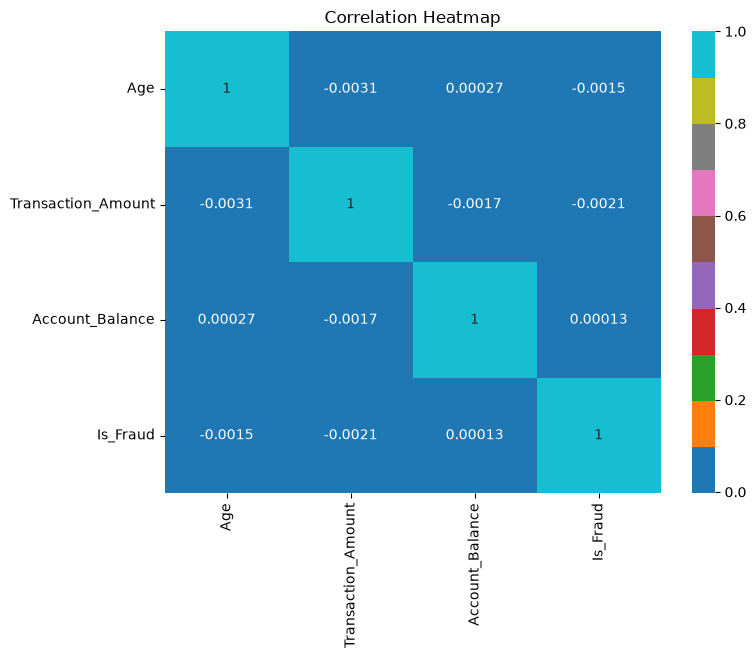

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include="number").corr(),
annot=True,
cmap="tab10")
plt.title("Correlation Heatmap")
plt.show()

### Key Insights

#### 1. The heatmap used to visualize the correlation matrix. 
#### 2. The heatmap helps identify relationships between variables quickly using colors.
#### 3. Since all values are near zero , the heatmap shows that the variables are mostly independent.

#  EDA Analysis

# Histogram

In [ ]:
fig = px.histogram(df,x="Is_Fraud",nbins=10,color="Customer_Name",title="Histogram Graph")
fig.show()

# Density Plot

In [ ]:
plt.figure(figsize=(10,5))
sns.kdeplot(df["Age"] , fill=True )
plt.title("Density plot of Age")
plt.grid("grey",alpha=0.3)
plt.show()

# PIE Chart

In [ ]:
type_counts = df['Transaction_Type'].value_counts().head(10)

plt.figure(figsize = (7,7))
plt.pie(type_counts, 
        labels=type_counts.index, 
        autopct='%1.1f%%', 
        startangle=140)
plt.title('Transactions by Type', fontsize=14, pad=20)
plt.show()

#### The pie chart represents the percentage distribution of different transaction types in the dataset. Each segment shows the share of a transaction category, helping us understand its contribution to the total transactions. The nearly equal percentages indicate a balanced distribution of transaction types.

# Violin chart

In [ ]:
fig = px.violin(df,y="Is_Fraud",title="violin graph")
fig.show()

# 3D Analysis

In [ ]:
fig = px.scatter_3d(df,
                    x="Transaction_Location",
                    y="Transaction_Device",
                    z="Transaction_Amount",
                    color="Account_Type",
                    hover_name="Customer_Name",
                    title="3D Analysis")
fig.show()

#### This 3D scatter plot visualizes the relationship between Transaction Location, Transaction Device, and Transaction Amount. Different colors represent different Account Types, making it easier to identify patterns and compare transactions across locations, devices, and account categories.
#### The visualization helps analyze transaction behavior from multiple dimensions and can assist in detecting trends, clusters, or unusual transaction activities.

# Donut Graph 

In [ ]:
data = df['Account_Type'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(data,labels=data.index,autopct='%1.1f%%',startangle=80,wedgeprops={'width':0.6})

plt.title("Account Type Distribution")
plt.show(